# Customer Basket Analysis Project

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 2. Load Datasets

In [2]:
basket = pd.read_csv('basket_details.csv')
customers = pd.read_csv('customer_details.csv')

print(basket.head())
print(customers.head())

   customer_id  product_id basket_date  basket_count
0     42366585    41475073  2019-06-19             2
1     35956841    43279538  2019-06-19             2
2     26139578    31715598  2019-06-19             3
3      3262253    47880260  2019-06-19             2
4     20056678    44747002  2019-06-19             2
   customer_id   sex  customer_age  tenure
0      9798859  Male          44.0      93
1     11413563  Male          36.0      65
2       818195  Male          35.0     129
3     12049009  Male          33.0      58
4     10083045  Male          42.0      88


## 3. Merge Data

In [3]:
df_final = pd.merge(basket, customers, on='customer_id', how='inner')
print(df_final.head())
print(df_final.info())

   customer_id  product_id basket_date  basket_count     sex  customer_age  \
0      4897641    34525548  2019-06-15             2    Male          40.0   
1     11623549    50394038  2019-06-18             2    Male          30.0   
2     11665521    41476812  2019-06-15             2  Female          51.0   
3      4193819     6455162  2019-06-15             2    Male          42.0   
4      1030589    38578121  2019-05-26             2    Male          45.0   

   tenure  
0     114  
1      63  
2      62  
3     117  
4     127  
<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   72 non-null     int64  
 1   product_id    72 non-null     int64  
 2   basket_date   72 non-null     str    
 3   basket_count  72 non-null     int64  
 4   sex           72 non-null     str    
 5   customer_age  72 non-null     float64
 6   tenure        72 no

## 4. Exploratory Analysis

In [4]:
gender_analysis = df_final.groupby('sex')['basket_count'].sum()
print(gender_analysis)

bins = [0, 20, 30, 40, 50, 100]
labels = ['0-20', '21-30', '31-40', '41-50', '50+']
df_final['age_group'] = pd.cut(df_final['customer_age'], bins=bins, labels=labels)
age_analysis = df_final.groupby('age_group')['basket_count'].sum()
print(age_analysis)

sex
Female     33
Male      122
Name: basket_count, dtype: int64
age_group
0-20      2
21-30    52
31-40    54
41-50    17
50+      20
Name: basket_count, dtype: int64


## 5. Visualizations

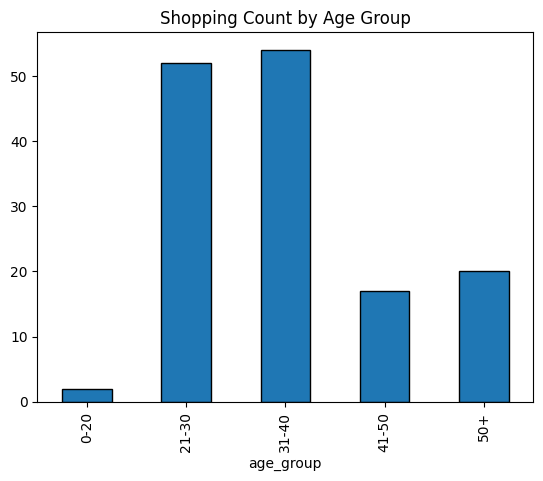

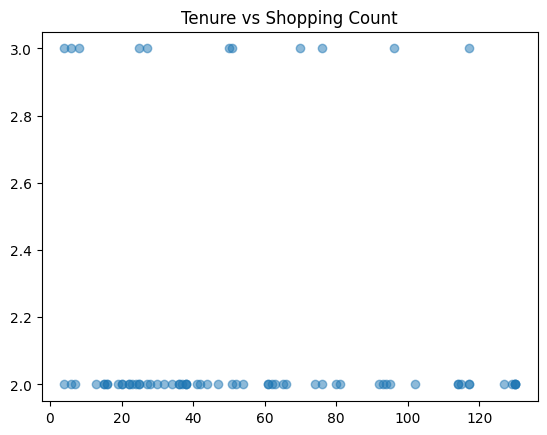

In [5]:
age_analysis.plot(kind='bar', edgecolor='black')
plt.title('Shopping Count by Age Group')
plt.show()

plt.scatter(df_final['tenure'], df_final['basket_count'], alpha=0.5)
plt.title('Tenure vs Shopping Count')
plt.show()

## 6. Time Analysis

In [6]:
df_final['basket_date'] = pd.to_datetime(df_final['basket_date'])
df_final['Month'] = df_final['basket_date'].dt.month_name()
monthly_sales = df_final.groupby('Month')['basket_count'].sum().sort_values(ascending=False)
print(monthly_sales)

Month
May     92
June    63
Name: basket_count, dtype: int64


## 7. Customer Segmentation

In [7]:
customer_summary = df_final.groupby('customer_id').agg({
    'basket_count':'sum',
    'tenure':'max',
    'customer_age':'first'
}).reset_index()

customer_summary.columns = ['CustomerID','TotalItems','MaxTenure','Age']

def classify_customer(row):
    if row['TotalItems'] >= 5:
        return 'VIP'
    elif row['TotalItems'] >= 3:
        return 'Regular'
    return 'New/Occasional'

customer_summary['CustomerType'] = customer_summary.apply(classify_customer, axis=1)
print(customer_summary.head())
print(customer_summary['CustomerType'].value_counts())

   CustomerID  TotalItems  MaxTenure   Age    CustomerType
0      380975           4        130  57.0         Regular
1      537173           4        130  43.0         Regular
2      851739           2        129  40.0  New/Occasional
3     1030589           2        127  45.0  New/Occasional
4     4193819           2        117  42.0  New/Occasional
CustomerType
New/Occasional    48
Regular           13
VIP                3
Name: count, dtype: int64


## 8. Feature Engineering

In [8]:
df_final['Efficiency_score'] = df_final['basket_count'] / df_final['tenure']
print(df_final[['customer_id','basket_count','tenure','Efficiency_score']].head())

   customer_id  basket_count  tenure  Efficiency_score
0      4897641             2     114          0.017544
1     11623549             2      63          0.031746
2     11665521             2      62          0.032258
3      4193819             2     117          0.017094
4      1030589             2     127          0.015748


## 9. Outlier Detection

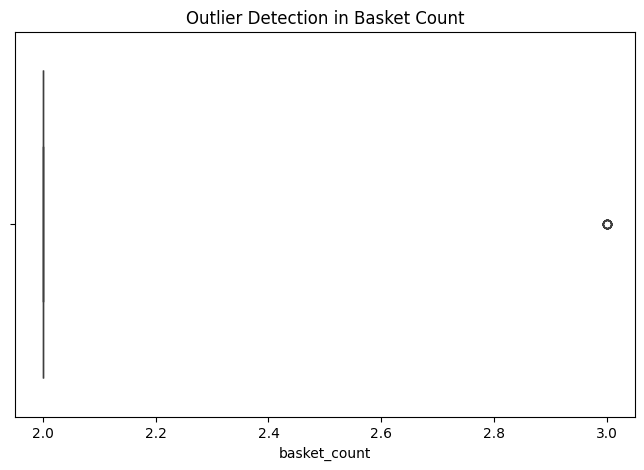

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_final['basket_count'])
plt.title('Outlier Detection in Basket Count')
plt.show()

## 10. Machine Learning Model

In [10]:
X = df_final[['customer_age', 'tenure']]
y = df_final['basket_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

prediction = model.predict([[25, 50]])
print('Prediction:', prediction[0])

y_pred = model.predict(X_test)
print('R2 Score:', r2_score(y_test, y_pred))

Prediction: 2.1846779153847837
R2 Score: -0.2670281636295624


c:\Users\Aftab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
